In [30]:
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np
from kcopy_fits import decay_model, fit_decays
from oitg import uncertainty_to_string
from oitg.results import find_results
from scipy.optimize import curve_fit
import graph_style as gs
import fig_helper as fh

gs.set_graph_style(1)


def make_2d_array(a, b, y):
    a_unique = np.unique(a)
    b_unique = np.unique(b)
    y_2d = np.zeros((len(a_unique), len(b_unique)))
    for i, a_val in enumerate(a_unique):
        for j, b_val in enumerate(b_unique):
            mask = (a == a_val) & (b == b_val)
            y_2d[i, j] = np.mean(y[mask])
    return a_unique, b_unique, y_2d


def load_hdf5_file_robust(filename):
    with h5py.File(filename, "r") as f:
        r = {}

        raw_expid = f["expid"][()]
        try:
            r["expid"] = json.loads(raw_expid)
        except Exception:
            if isinstance(raw_expid, (bytes, bytearray)):
                r["expid"] = raw_expid.decode(errors="replace")
            else:
                r["expid"] = str(raw_expid)
            r["expid_parse_error"] = "expid is not valid JSON in this result file"

        for k in ["artiq_version", "start_time"]:
            r[k] = f[k][()]

        ds = {}
        r["datasets"] = ds
        for k in f["datasets"]:
            ds[k] = f["datasets"][k][()]

        ar = {}
        r["archive"] = ar
        for k in f["archive"]:
            ar[k] = f["archive"][k][()]

        return r


def purity_from_pops(results):
    M0 = results["p_10"] + results["p_11"] - results["p_00"] - results["p_01"]
    M1 = results["p_01"] + results["p_11"] - results["p_00"] - results["p_10"]
    M01 = results["p_00"] + results["p_11"] - results["p_01"] - results["p_10"]
    results["purity"] = 0.5 * (1 + M0 - M1 + M01)

def tr_rho2Z_from_pops(results):
    M0 = results["p_10"] + results["p_11"] - results["p_00"] - results["p_01"]
    M1 = results["p_01"] + results["p_11"] - results["p_00"] - results["p_10"]
    results["tr_rho2Z"] = 0.5 * (M0 + M1)


def load_data(rid, day):
    results = find_results(
        day=day,
        rid=rid,
        experiment="fastgates",
    )
    if not results:
        raise FileNotFoundError(
            f"No results found for rid={rid}, day={day}, experiment=fastgates"
        )

    result_path = next(iter(results.values())).path
    result = load_hdf5_file_robust(result_path)
    processed_results = {}
    # print(result["datasets"].keys())

    def get_ds(name):
        return result["datasets"][f"vd_rbm.points.{name}"]

    a = np.array(get_ds("axis_0"))
    b = np.array(get_ds("axis_1"))

    # z = get_ds("channel_readout_Z_corr")
    p_root = "channel_measurement_camera_readout_p_"
    z = get_ds(f"{p_root}0")
    a_uniq, b_uniq, z_2d = make_2d_array(a, b, z)
    n_seeds = len(b_uniq)
    processed_results["rid"] = rid
    processed_results["day"] = day
    processed_results["a"] = a_uniq  # num cliffords
    processed_results["b"] = b_uniq  # seed
    # processed_results["purity"] = make_2d_array(a, b, get_ds("channel_readout_purity"))[
    #     2
    # ].mean(axis=1)

    processed_results["tr_rho2Z_avg"] = make_2d_array(
        a, b, get_ds("channel_readout_tr_rho2Z")
    )[2].mean(axis=1)

    processed_results["z_left"] = (
        2 * make_2d_array(a, b, get_ds(f"{p_root}0"))[2].mean(axis=1) - 1
    )
    processed_results["z_left_err"] = (
        2
        * make_2d_array(a, b, get_ds(f"{p_root}err_0"))[2].mean(axis=1)
        / np.sqrt(n_seeds)
    )
    processed_results["z_right"] = (
        2 * make_2d_array(a, b, get_ds(f"{p_root}1"))[2].mean(axis=1) - 1
    )
    processed_results["z_right_err"] = (
        2
        * make_2d_array(a, b, get_ds(f"{p_root}err_1"))[2].mean(axis=1)
        / np.sqrt(n_seeds)
    )
    load_kcopy_results(result, processed_results)
    purity_from_pops(processed_results)
    tr_rho2Z_from_pops(processed_results)
    processed_results["z_corrected"] = (
        processed_results["tr_rho2Z"] / processed_results["purity"]
    )
    print(f"Purity: {processed_results['purity']}")
    print(f"tr(rho^2 Z): {processed_results['tr_rho2Z']}")
    print(f"tr_rho2Z_from_pops: {processed_results['tr_rho2Z_avg']}")
    return result, processed_results


def load_kcopy_results(raw_results, processed_results):
    m = fh.SO3Model()
    def get_ds(results, name):
        return results["datasets"][f"vd_rbm.points.{name}"]

    a = np.array(get_ds(raw_results, "axis_0"))
    b = np.array(get_ds(raw_results, "axis_1"))
    p_ff = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_00"))[2].mean(
        axis=1
    )
    p_fs = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_01"))[2].mean(
        axis=1
    )
    p_sf = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_10"))[2].mean(
        axis=1
    )
    p_ss = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_11"))[2].mean(
        axis=1
    )
    p_ff_err = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_00"))[2].std(
        axis=1
    )
    p_fs_err = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_01"))[2].std(
        axis=1
    )
    p_sf_err = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_10"))[2].std(
        axis=1
    )
    p_ss_err = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_11"))[2].std(
        axis=1
    )
    a_uniq = make_2d_array(a, b, get_ds(raw_results, "channel_readout_p_00"))[0]
    # fit_dict = fit_decays(a_uniq, p_11, p_10, p_01, p_00)
    pops = [p_ss, p_sf, p_fs, p_ff]
    errs = [
        p_ss_err,
        p_sf_err,
        p_fs_err,
        p_ff_err
    ]
    pops, errs = m.convert_pops(pops, errs)
    P = np.concatenate(pops)
    sigmas = np.concatenate(errs)
    # check for zero uncertainties and replace with small value to avoid issues in curve_fit
    for i in range(len(sigmas)):
        if sigmas[i] == 0:
            print(
                f"Warning: zero uncertainty for data point {i}, replacing with large value."
            )
            sigmas[i] = 1.0
    popt, pcov = curve_fit(
        m.model,
        a_uniq,
        P,
        # sigma=sigmas,
        p0=m.p0,
        # absolute_sigma=True,
        bounds=m.bounds,
        maxfev=10000,
    )
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    plot_kcopy_results(ax, a_uniq, pops, popt, pcov, m.model)
    plt.show()
    perr = np.sqrt(np.diag(pcov))
    residuals = P - m.model(a_uniq, *popt)
    rss = float(np.sum(residuals**2))
    fit_dict = {
        "popt": popt,
        "perr": perr,
        "rss": rss,
    }

    processed_results.update(
        {
            "p_10": p_sf,
            "p_01": p_fs,
            "p_00": p_ff,
            "p_11": p_ss,
            "e_corr": fit_dict["popt"][0],
            "e_right": fit_dict["popt"][1],
            "e_left": fit_dict["popt"][2],
            "e_spam": fit_dict["popt"][3],
            "e_corr_err": fit_dict["perr"][0],
            "e_right_err": fit_dict["perr"][1],
            "e_left_err": fit_dict["perr"][2],
            "e_spam_err": fit_dict["perr"][3],
        }
    )


def rb_fit(m, e_spam, e_cliff):
    m = np.array(m)
    # Factor of 2 comes from Hilbert space dimension for single qubit RB
    return (1 - 2 * e_spam) * (1 - 2 * e_cliff) ** m


def corrected_analytic(m, e_spam, e_corr, e_right, e_left):
    corr_l = (1 - 2*e_corr) * (1 - 2*e_left)
    corr_r = (1 - 2*e_corr) * (1 - 2*e_right)
    lr = (1 - 2*e_left) * (1 - 2*e_right)
    s = 1 - 2*e_spam

    tr_Zrho2 = (corr_l**m + corr_r**m) * s / 2
    purity = (1 + lr**m * s**2) / 2

    return tr_Zrho2, purity, tr_Zrho2 / purity

def corrected_analytic(m, e_spam, e_corr, e_right, e_left):
    Z_corr = (1-2*e_corr)**m * np.cosh(m*(e_left-e_right))/np.cosh(m*(e_left+e_right))

    return 0, 0, Z_corr

def plot_kcopy_results(ax, num_gates, Ps, popt, pcov, model_func):
    P00, P01, P10, P11 = Ps
    x_min = 1
    x_max = max(num_gates) * 2
    reshape_fac = 4
    ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
    ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

    ax.errorbar(num_gates, P00,  fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8)
    ax.errorbar(num_gates, P11,  fmt="v", label="$\\mathcal{P}_{FF}$", color="#017517", alpha=0.8)
    P0110 = [a+b for a, b in zip(P01, P10)]
    ax.errorbar(num_gates, P0110, fmt="s", label="$\\mathcal{P}_{SF}+\\mathcal{P}_{FS}$", color=gs.get_color(3), alpha=0.8)
    x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
    x_fit = np.round(x_fit).astype(int)
    P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
    ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha(), linestyle="-")
    ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha(), linestyle="-")
    P0110_fit = P_fit[1] + P_fit[2]
    ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha(), linestyle="-")
    ax.set_ylabel("Populations")
    ax.legend(loc="upper right")
    ax.set_ylim(-0.05, 1.0)
    ax.set_xlim(x_min, x_max)
    # add text with fit parameters
    fit_str = (
        f"Fit parameters:\n"
        f"$e_{{corr}} = {uncertainty_to_string(popt[0], np.sqrt(np.diag(pcov))[0])}$\n"
        f"$e_{{right}} = {uncertainty_to_string(popt[1], np.sqrt(np.diag(pcov))[1])}$\n"
        f"$e_{{left}} = {uncertainty_to_string(popt[2], np.sqrt(np.diag(pcov))[2])}$\n"
        f"$e_{{spam}} = {uncertainty_to_string(popt[3], np.sqrt(np.diag(pcov))[3])}$"
    )
    ax.text(0.05, 0.95, fit_str, transform=ax.transAxes, fontsize=9, verticalalignment="top")
    
    ax.set_xscale("log")

def plot_results(
    res_without_b,
    res_with_b,
    offset,
    seed_offset=1,
    show_purity=False,
    show_tr_rho2Z=False,
):
    plt.figure(figsize=(8, 4))
    plt.errorbar(
        res_without_b["a"],
        res_without_b["z_left"],
        yerr=res_without_b["z_left_err"],
        fmt="s",
        label=f"Raw left (rid {res_without_b['rid']})",
        c="C0",
    )
    popt_left, pcov = curve_fit(
        rb_fit, res_without_b["a"], res_without_b["z_left"], p0=[0.01, 0.01], sigma=res_without_b["z_left_err"]
    )
    errs = np.sqrt(np.diag(pcov))
    a = np.array(res_without_b["a"])
    smooth_a = np.logspace(0, np.log10(max(a)), 100)
    plt.plot(
        smooth_a,
        rb_fit(smooth_a, *popt_left),
        label=f"Fit left: es={uncertainty_to_string(popt_left[0], errs[0])}, e={uncertainty_to_string(popt_left[1], errs[1])}",
        c="C0",
        ls="--",
    )
    plt.errorbar(
        res_without_b["a"],
        res_without_b["z_right"],
        yerr=res_without_b["z_right_err"],
        fmt="d",
        label=f"Raw right (rid {res_without_b['rid']})",
        c="C1",
    )
    popt_right, pcov = curve_fit(
        rb_fit, res_without_b["a"], res_without_b["z_right"], p0=[0.01, 0.01], sigma=res_without_b["z_right_err"]
    )
    errs = np.sqrt(np.diag(pcov))
    plt.plot(
        smooth_a,
        rb_fit(smooth_a, *popt_right),
        label=f"Fit right: es={uncertainty_to_string(popt_right[0], errs[0])}, e={uncertainty_to_string(popt_right[1], errs[1])}",
        c="C1",
        ls="--",
    )
    if (
        "e_corr" in res_without_b
        and "e_right" in res_without_b
        and "e_left" in res_without_b
    ):
        plt.plot(
            smooth_a,
            corrected_analytic(
                smooth_a,
                res_without_b["e_spam"],
                res_without_b["e_corr"],
                res_without_b["e_right"],
                res_without_b["e_left"],
            )[2],
            label=f"Corr. theory (es, el, er, ec) =\n ({res_without_b['e_spam']:.2f}, {res_without_b['e_left']:.2f}, {res_without_b['e_right']:.2f}, {res_without_b['e_corr']:.2f})",
            c="C2",
            ls="--",
        )

    if show_purity:
        plt.plot(
            res_with_b["a"],
            res_with_b["purity"],
            label=f"Purity (rid {res_with_b['rid']})",
            c="C3",
            marker="x",
            ls="",
        )
        if "e_corr" in res_without_b:
            plt.plot(
                smooth_a,
                corrected_analytic(
                    smooth_a,
                    res_without_b["e_spam"],
                    res_without_b["e_corr"],
                    res_without_b["e_right"],
                    res_without_b["e_left"],
                )[1],
                label="Purity analytic",
                c="C3",
                ls=":",
            )
    if show_tr_rho2Z:
        plt.plot(
            res_with_b["a"],
            res_with_b["tr_rho2Z"],
            label="tr(rho^2 Z)",
            c="C4",
            ls="--",
        )
    plt.scatter(
        res_with_b["a"],
        res_with_b["z_corrected"],
        label=f"Corrected (rid {res_with_b['rid']})",
        c="C2",
    )
    plt.xlabel("Number of Cliffords")
    plt.ylabel("Z")
    seed_str = "Same seed" if seed_offset == 0 else "Different seeds"
    plt.title(f"VD RBM; {seed_str}; $\\Delta f = {offset / 1e3:.1f}$ kHz")
    plt.legend(fontsize="small", loc="lower left")
    plt.xscale("log")
    plt.grid(True, which="both", c="gray", alpha=0.5)
    plt.show()

In [31]:
false = False
true = True
rids_to_test = [
    {
        "rid": 130201,
        "date": "2026-06-11",
        "do_b_circ": false,
        "freq_offset": -1000.0,
        "seed_offset": 1,
    },
    {
        "rid": 130202,
        "date": "2026-06-11",
        "do_b_circ": false,
        "freq_offset": -1000.0,
        "seed_offset": 0,
    },
    {
        "rid": 130203,
        "date": "2026-06-11",
        "do_b_circ": true,
        "freq_offset": -1000.0,
        "seed_offset": 1,
    },
    {
        "rid": 130204,
        "date": "2026-06-11",
        "do_b_circ": true,
        "freq_offset": -1000.0,
        "seed_offset": 0,
    },
]
# Second set
# rids_to_test = [
#     {
#         "rid": 129968,
#         "date": "2026-06-09",
#         "do_b_circ": false,
#         "freq_offset": -1000.0,
#         "seed_offset": 1,
#     },
#     {
#         "rid": 129970,
#         "date": "2026-06-09",
#         "do_b_circ": true,
#         "freq_offset": -1000.0,
#         "seed_offset": 1,
#     },
#     {
#         "rid": 129967,
#         "date": "2026-06-09",
#         "do_b_circ": false,
#         "freq_offset": -1000.0,
#         "seed_offset": 0,
#     },
#     {
#         "rid": 129969,
#         "date": "2026-06-09",
#         "do_b_circ": true,
#         "freq_offset": -1000.0,
#         "seed_offset": 0,
#     },
# ]

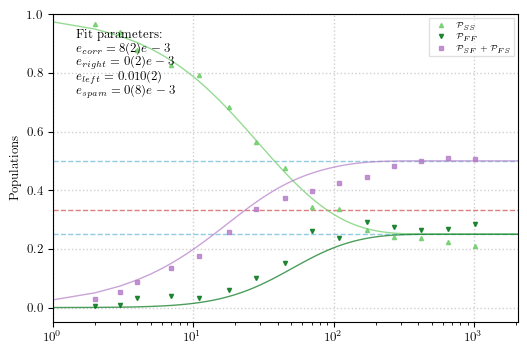

Purity: [0.979 0.968 0.956 0.959 0.933 0.906 0.86  0.824 0.768 0.701 0.639 0.527
 0.526 0.509 0.507]
tr(rho^2 Z): [ 0.962   0.9285  0.846   0.7895  0.7595  0.6245  0.463   0.3265  0.083
  0.1    -0.026  -0.033  -0.028  -0.0465 -0.0775]
tr_rho2Z_from_pops: [ 0.962   0.9285  0.846   0.7895  0.7595  0.6245  0.463   0.3265  0.083
  0.1    -0.026  -0.033  -0.028  -0.0465 -0.0775]


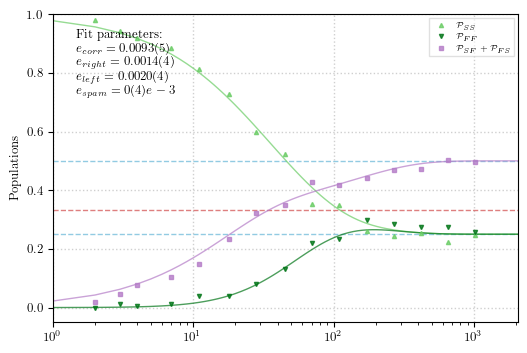

Purity: [0.979 0.954 0.918 0.893 0.855 0.753 0.697 0.65  0.594 0.595 0.579 0.517
 0.568 0.48  0.498]
tr(rho^2 Z): [ 0.981   0.9335  0.913   0.8745  0.7735  0.689   0.516   0.392   0.133
  0.117  -0.035  -0.039  -0.0225 -0.0495 -0.0125]
tr_rho2Z_from_pops: [ 0.981   0.9335  0.913   0.8745  0.7735  0.689   0.516   0.392   0.133
  0.117  -0.035  -0.039  -0.0225 -0.0495 -0.0125]


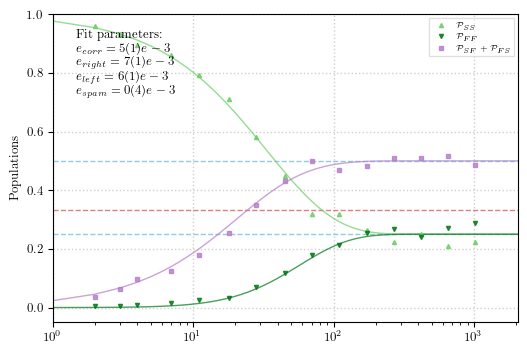

Purity: [0.962 0.934 0.909 0.881 0.832 0.717 0.651 0.54  0.494 0.545 0.529 0.481
 0.497 0.498 0.523]
tr(rho^2 Z): [ 0.9555  0.928   0.887   0.846   0.7675  0.678   0.513   0.3325  0.1385
  0.105   0.013  -0.0445  0.0085 -0.063  -0.066 ]
tr_rho2Z_from_pops: [ 0.9555  0.928   0.887   0.846   0.7675  0.678   0.513   0.3325  0.1385
  0.105   0.013  -0.0445  0.0085 -0.063  -0.066 ]


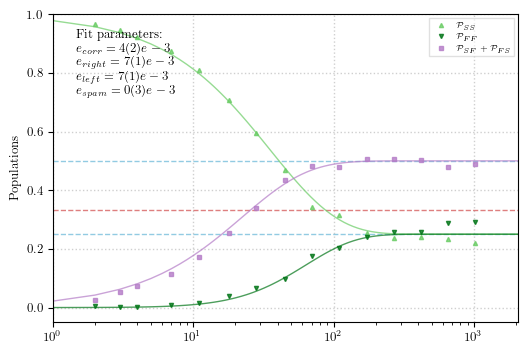

Purity: [0.973 0.948 0.912 0.886 0.835 0.74  0.677 0.576 0.529 0.533 0.526 0.483
 0.495 0.517 0.505]
tr(rho^2 Z): [ 0.962   0.9435  0.92    0.8655  0.7925  0.6685  0.528   0.3715  0.1695
  0.1125  0.011  -0.021  -0.0155 -0.056  -0.073 ]
tr_rho2Z_from_pops: [ 0.962   0.9435  0.92    0.8655  0.7925  0.6685  0.528   0.3715  0.1695
  0.1125  0.011  -0.021  -0.0155 -0.056  -0.073 ]
Support ratio: [1.20935294 1.64192405 0.80825455 0.72985841 1.1938098  1.03956661
 1.00730479 1.01033166 0.94738686 1.01475874 0.97531579 0.99000714
 0.93236823 0.97859946 0.8847562 ]
e_raw: 0.0112(7)
e_spam: 0.0001 ± 0.0044, e_corr: 0.0093 ± 0.0005, e_right: 0.0014 ± 0.0004, e_left: 0.0020 ± 0.0004
e_tot: 0.0112 ± 0.0006
e_corrected: 0.011(1)
Support ratio: [5.624      8.56166667 3.88390909 3.37297143 2.56694574 6.17723077
 2.14641304 1.61089157 1.13946554 1.08380682 0.98213566 0.94552426
 1.03673081 0.94007487 0.95898132]
e_spam: 0.0001 ± 0.0034, e_corr: 0.0038 ± 0.0015, e_right: 0.0067 ± 0.0015, e_left: 0.0074

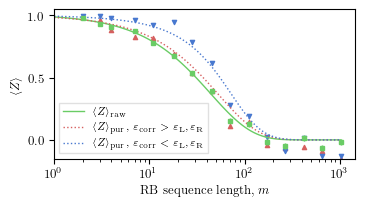

In [32]:
show_scatter = True


def plot_pres_results(
    results_without_b,
    results_with_b,
):
    fig_width = gs.get_fig_width()/1.5
    fig_height = fig_width  /2
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    c_arr = ["C1", "C1"]
    c_2q_arr = ["C2", "C0"]
    labels = [
        "$\\varepsilon_\\mathrm{corr}>\\varepsilon_\\mathrm{L}, \\varepsilon_\\mathrm{R}$",
        "$\\varepsilon_\\mathrm{corr}<\\varepsilon_\\mathrm{L}, \\varepsilon_\\mathrm{R}$",
    ]
    symbols = ["^", "v"]
    for res_without_b, res_with_b in zip(results_without_b, results_with_b):


        supp_ratio = (1-res_without_b["z_left"])/ (1-res_with_b["z_corrected"]) 
        print(f"Support ratio: {supp_ratio}")
        seed_offset = res_without_b["seed_offset"]
        if seed_offset == 0:
            if show_scatter:
                ax.errorbar(
                    res_without_b["a"],
                    res_without_b["z_left"],
                    yerr=res_without_b["z_left_err"],
                    fmt="s",
                    label="",
                    c=c_arr[seed_offset],
                )
            popt_left, pcov = curve_fit(
                rb_fit, res_without_b["a"], res_without_b["z_left"], p0=[0.01, 0.01]
            )
            errs = np.sqrt(np.diag(pcov))
            print(
                "e_raw:",
                uncertainty_to_string(popt_left[1], errs[1]),
            )
            a = np.array(res_without_b["a"])
            smooth_a = np.logspace(0, np.log10(max(a)), 100)
            ax.plot(
                smooth_a,
                rb_fit(smooth_a, *popt_left),
                label="$\\langle Z\\rangle_\\mathrm{raw}$",
                c=c_arr[seed_offset],
                ls="-",
            )
        if (
            "e_corr" in res_without_b
            and "e_right" in res_without_b
            and "e_left" in res_without_b
        ):
            # print(
            #     f"e_spam: {uncertainty_to_string(res_without_b['e_spam'], res_without_b['e_spam_err'])}, e_corr: {uncertainty_to_string(res_without_b['e_corr'], res_without_b['e_corr_err'])}, e_right: {uncertainty_to_string(res_without_b['e_right'], res_without_b['e_right_err'])}, e_left: {uncertainty_to_string(res_without_b['e_left'], res_without_b['e_left_err'])}"
            # )
            print(
                f"e_spam: {res_without_b['e_spam']:.4f} ± {res_without_b['e_spam_err']:.4f}, e_corr: {res_without_b['e_corr']:.4f} ± {res_without_b['e_corr_err']:.4f}, e_right: {res_without_b['e_right']:.4f} ± {res_without_b['e_right_err']:.4f}, e_left: {res_without_b['e_left']:.4f} ± {res_without_b['e_left_err']:.4f}"
            )
            e_tot = res_without_b["e_corr"] +  res_without_b["e_left"]
            e_tot_err = np.sqrt(res_without_b["e_corr_err"]**2 + res_without_b["e_left_err"]**2)
            print(f"e_tot: {e_tot:.4f} ± {e_tot_err:.4f}")
            ax.plot(
                smooth_a,
                corrected_analytic(
                    smooth_a,
                    res_without_b["e_spam"],
                    res_without_b["e_corr"],
                    res_without_b["e_right"],
                    res_without_b["e_left"],
                )[2],
                label="$\\langle Z\\rangle_\\mathrm{pur}$, " + f"{labels[seed_offset]}",
                c=c_2q_arr[seed_offset],
                ls="dotted",
            )
        if show_scatter:
            ax.scatter(
                res_with_b["a"],
                res_with_b["z_corrected"],
                label="",
                c=c_2q_arr[seed_offset],
                marker=symbols[seed_offset],
            )
            popt_left, pcov = curve_fit(
                rb_fit, res_with_b["a"], res_with_b["z_corrected"], p0=[0.01, 0.01]
            )
            print(
                "e_corrected:",
                uncertainty_to_string(popt_left[1], np.sqrt(np.diag(pcov))[1]),
            )
    ax.set_xlabel("RB sequence length, $m$")
    ax.set_ylabel("$\\langle Z\\rangle$")
    ax.legend(fontsize="small", loc="lower left")
    ax.set_xscale("log")

    # ax.axhline(1, color="grey", linewidth=1.5)
    # ax.text(
    #     0.9,
    #     0.99,
    #     "$\\varepsilon=0$",
    #     transform=plt.gca().get_yaxis_transform(),
    #     ha="right",
    #     va="top",
    #     fontsize="medium",
    # )
    x_min, x_max = plt.xlim()
    ax.set_xlim(1, x_max)
    # ax.set_xlim(1, 30)
    ax.set_ylim(-0.15, 1.05)
    ax.set_yticks([0,0.5,1.0])
    # ax.set_ylim(0.5, 1.05)
    ax.grid(False)


freq_offset_uniq = np.unique([d["freq_offset"] for d in rids_to_test])
results_without_b = []
results_with_b = []
offset = -1000.0
for seed_offset in [0, 1]:
    rid_with_b = next(
        d
        for d in rids_to_test
        if d["freq_offset"] == offset
        and d["do_b_circ"]
        and d["seed_offset"] == seed_offset
    )
    rid_without_b = next(
        d
        for d in rids_to_test
        if d["freq_offset"] == offset
        and not d["do_b_circ"]
        and d["seed_offset"] == seed_offset
    )
    _, res_with_b = load_data(rid_with_b["rid"], rid_with_b["date"])
    res_with_b["seed_offset"] = seed_offset
    results_with_b.append(res_with_b)
    _, res_without_b = load_data(rid_without_b["rid"], rid_without_b["date"])
    res_without_b["seed_offset"] = seed_offset
    results_without_b.append(res_without_b)


plot_pres_results(
    results_without_b,
    results_with_b,
)
f_name = "..\\..\\pdf_figure\\ch6\\err_inj.pdf"
# plt.savefig(f_name, bbox_inches="tight")

In [21]:
import numpy as np
e_raw = 11.2
e_raw_err = 0.6
e_corr = 4
e_corr_err = 1
r = e_raw / e_corr
r_err = r * np.sqrt((e_raw_err / e_raw) ** 2 + (e_corr_err / e_corr) ** 2)
print(f"e_raw: {e_raw:.2f} ± {e_raw_err:.2f}, e_corr: {e_corr:.2f} ± {e_corr_err:.2f}, ratio: {r:.2f} ± {r_err:.2f}")

e_raw: 11.20 ± 0.60, e_corr: 4.00 ± 1.00, ratio: 2.80 ± 0.72


In [22]:

e_raw = 11.2
e_raw_err = 0.6
e_corr = 9.3
e_corr_err = 0.5
r = e_raw / e_corr
r_err = r * np.sqrt((e_raw_err / e_raw) ** 2 + (e_corr_err / e_corr) ** 2)
print(f"e_raw: {e_raw:.2f} ± {e_raw_err:.2f}, e_corr: {e_corr:.2f} ± {e_corr_err:.2f}, ratio: {r:.2f} ± {r_err:.2f}")

e_raw: 11.20 ± 0.60, e_corr: 9.30 ± 0.50, ratio: 1.20 ± 0.09
